In [1]:
%pip install numpy pandas matplotlib scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.optimize import minimize
from scipy.stats import norm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
features = ["PT1", "PT2", "P1", "P2", "TotalPT", "VertexChisq", "Isolation", "MASS"]

#load background mass values
background = pd.read_csv("data/background_combinatorial.txt", sep=r"\s+", header=None, names=features)
background = background.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
bkg_mass = background["MASS"].to_numpy()

#load BDT efficiencies from bdt.ipynb
with open("bdt_results.json") as fh:
    bdt = json.load(fh)
sig_eff = bdt["signal_efficiency"]
bkg_eff = bdt["background_efficiency"]
print(f"signal efficiency from BDT: {sig_eff:.4f}")
print(f"background efficiency from BDT: {bkg_eff:.4f}")

signal efficiency from BDT: 0.9305
background efficiency from BDT: 0.0726


(a)

We first fit the background mass distribution to an exponential to establish the shape. The exponential is defined on [4, 6] GeV and normalised accordingly.

In [3]:
MASS_LO, MASS_HI = 4.0, 6.0

#normalised exponential PDF on [4, 6]
def exp_pdf(m, lam):
    norm_factor = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    return np.exp(-lam * m) / norm_factor

#fit the background sample to get the exponential slope
def nll_bkg(params, masses):
    lam = params[0]
    if lam <= 0:
        return 1e10
    return -np.sum(np.log(exp_pdf(masses, lam)))

result_bkg = minimize(nll_bkg, x0=[0.5], args=(bkg_mass,), method="Nelder-Mead")
lam_fit = result_bkg.x[0]
print(f"fitted exponential slope: lambda = {lam_fit:.4f}")

#save for later use
with open("fit_params.json", "w") as fh:
    json.dump({"lam_bkg": float(lam_fit)}, fh, indent=2)
print("saved fit_params.json")

fitted exponential slope: lambda = 0.0283
saved fit_params.json


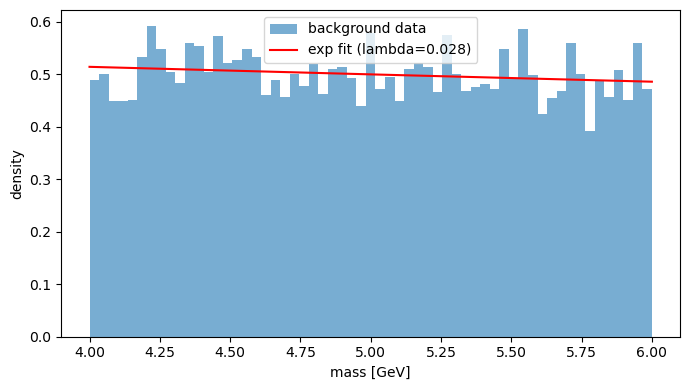

In [4]:
#plot the background mass distribution with the fitted exponential overlaid
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(MASS_LO, MASS_HI, 60)
ax.hist(bkg_mass, bins=bins, density=True, alpha=0.6, label="background data")
m_range = np.linspace(MASS_LO, MASS_HI, 300)
ax.plot(m_range, exp_pdf(m_range, lam_fit), color="red", label=f"exp fit (lambda={lam_fit:.3f})")
ax.set_xlabel("mass [GeV]")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.savefig("plots/background_fit.png", dpi=150, bbox_inches="tight")
plt.show()

Now we set up the composite PDF and generate 1000 toy datasets for one year of running. After BDT selection the expected yields are 50 * sig_eff signal and 2000 * bkg_eff background events.

In [5]:
#fixed signal parameters from the problem setup
MU_SIG  = 5.0    # true mass [GeV]
SIG_SIG = 0.03   # detector resolution [GeV]

#expected events per year after BDT selection
N_SIG_YEAR = 50   * sig_eff
N_BKG_YEAR = 2000 * bkg_eff
print(f"expected per year: {N_SIG_YEAR:.1f} signal, {N_BKG_YEAR:.1f} background")

def sample_exp(lam, n, rng):
    #inverse CDF sampling of exponential on [4, 6]
    u = rng.uniform(0, 1, size=n)
    return -np.log(np.exp(-lam * MASS_LO) - u * (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI))) / lam

def generate_toy(n_sig_mean, n_bkg_mean, lam, rng):
    #poisson fluctuations on the yields
    n_sig = rng.poisson(n_sig_mean)
    n_bkg = rng.poisson(n_bkg_mean)
    sig_masses = rng.normal(MU_SIG, SIG_SIG, size=n_sig)
    bkg_masses = sample_exp(lam, n_bkg, rng)
    #keep only events within the fit window
    masses = np.concatenate([sig_masses, bkg_masses])
    return masses[(masses >= MASS_LO) & (masses <= MASS_HI)]

rng = np.random.default_rng(seed=42)
N_TOYS = 1000
toys = [generate_toy(N_SIG_YEAR, N_BKG_YEAR, lam_fit, rng) for _ in range(N_TOYS)]
print(f"generated {N_TOYS} toy datasets")
print(f"median toy size: {int(np.median([len(t) for t in toys]))} events")

expected per year: 46.5 signal, 145.2 background
generated 1000 toy datasets
median toy size: 192 events


(b)

We fit each toy dataset with the composite PDF (signal fraction f_s and background slope lambda free) and check whether the average recovered signal fraction is consistent with the true value.

In [6]:
#composite PDF: f_s * Gauss + (1 - f_s) * Exp
def composite_pdf(m, fs, lam):
    sig_component = norm.pdf(m, MU_SIG, SIG_SIG)
    bkg_component = exp_pdf(m, lam)
    return fs * sig_component + (1 - fs) * bkg_component

def nll_composite(params, masses):
    fs, lam = params
    if fs < 0 or fs > 1 or lam <= 0:
        return 1e10
    pdf_vals = composite_pdf(masses, fs, lam)
    if np.any(pdf_vals <= 0):
        return 1e10
    return -np.sum(np.log(pdf_vals))

def fit_toy(masses):
    res = minimize(nll_composite, x0=[0.02, lam_fit], args=(masses,), method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-5, "maxiter": 5000})
    return float(res.x[0]), float(res.x[1]), float(res.fun)

#true signal fraction
f_true = N_SIG_YEAR / (N_SIG_YEAR + N_BKG_YEAR)
print(f"true signal fraction: {f_true:.5f}")

#fit all toys
fit_results = [fit_toy(toy) for toy in toys]
fs_vals   = np.array([r[0] for r in fit_results])
lam_vals  = np.array([r[1] for r in fit_results])
nll1_vals = np.array([r[2] for r in fit_results])

print(f"average fitted signal fraction: {fs_vals.mean():.5f}  (true: {f_true:.5f})")
print(f"std of fitted signal fraction:  {fs_vals.std():.5f}")

true signal fraction: 0.24267


average fitted signal fraction: 0.24281  (true: 0.24267)
std of fitted signal fraction:  0.03488


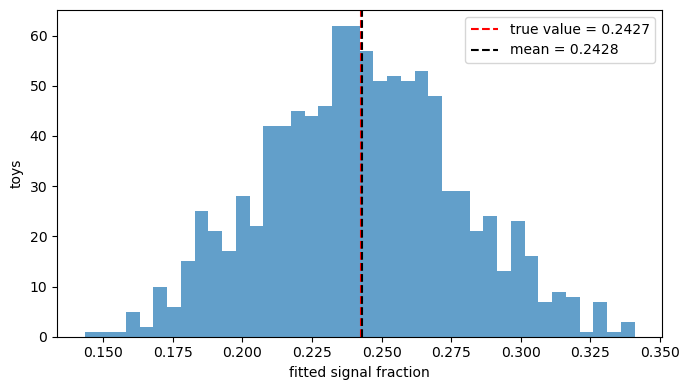

In [7]:
#plot distribution of fitted signal fractions
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fs_vals, bins=40, alpha=0.7)
ax.axvline(f_true, color="red", linestyle="--", label=f"true value = {f_true:.4f}")
ax.axvline(fs_vals.mean(), color="black", linestyle="--", label=f"mean = {fs_vals.mean():.4f}")
ax.set_xlabel("fitted signal fraction")
ax.set_ylabel("toys")
ax.legend()
plt.tight_layout()
plt.savefig("plots/toy_signal_fractions.png", dpi=150, bbox_inches="tight")
plt.show()

(c)

We calculate the significance for each toy using Wilks' theorem: fit with and without a signal component, then use q = 2 * delta_NLL as the test statistic. The significance is sqrt(q).

In [8]:
def nll_bkg_only(params, masses):
    lam = params[0]
    if lam <= 0:
        return 1e10
    return -np.sum(np.log(exp_pdf(masses, lam)))

def fit_bkg_only(masses):
    res = minimize(nll_bkg_only, x0=[lam_fit], args=(masses,), method="Nelder-Mead")
    return float(res.fun)

#compute significance for each toy via Wilks theorem
nll0_vals = np.array([fit_bkg_only(toy) for toy in toys])

#test statistic q = 2*(NLL_bkg - NLL_sig+bkg), clipped at 0
q_vals = np.clip(2 * (nll0_vals - nll1_vals), 0, None)
significance = np.sqrt(q_vals)

print(f"median significance: {np.median(significance):.2f} sigma")
print(f"fraction of toys with > 5 sigma: {(significance > 5).mean():.3f}")

median significance: 10.00 sigma
fraction of toys with > 5 sigma: 1.000


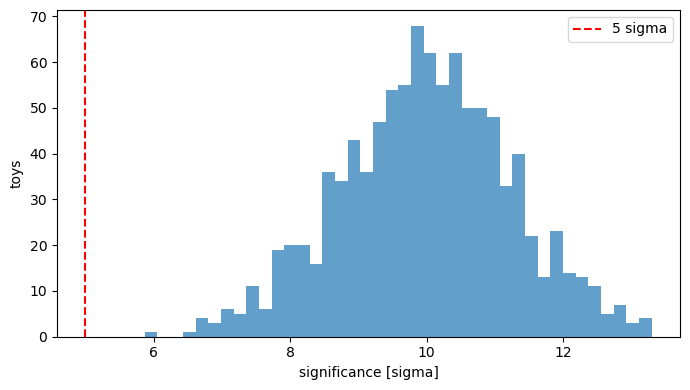

In [9]:
#plot the significance distribution across toys
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(significance, bins=40, alpha=0.7)
ax.axvline(5, color="red", linestyle="--", label="5 sigma")
ax.set_xlabel("significance [sigma]")
ax.set_ylabel("toys")
ax.legend()
plt.tight_layout()
plt.savefig("plots/toy_significance.png", dpi=150, bbox_inches="tight")
plt.show()

(d)

We scan over different experiment durations and for each duration generate 500 toys, then find the shortest duration where more than 95% of toys exceed 5 sigma.

In [10]:
def prob_discovery_at(duration_years, n_toys=500, rng_seed=0):
    rng_local = np.random.default_rng(rng_seed)
    n_sig_mean = 50   * sig_eff * duration_years
    n_bkg_mean = 2000 * bkg_eff * duration_years
    sigs = []
    for _ in range(n_toys):
        toy = generate_toy(n_sig_mean, n_bkg_mean, lam_fit, rng_local)
        _, _, nll1 = fit_toy(toy)
        nll0 = fit_bkg_only(toy)
        q = max(0.0, 2 * (nll0 - nll1))
        sigs.append(np.sqrt(q))
    return float((np.array(sigs) > 5).mean())

#scan in 0.1-year steps from 0.1 to 3 years
durations = np.round(np.arange(0.1, 3.05, 0.1), 1)
probs = []

for T in durations:
    p = prob_discovery_at(T, n_toys=500, rng_seed=int(T * 100))
    probs.append(p)
    print(f"T = {T:4.1f} yr  ->  P(Z > 5 sigma) = {p:.3f}")

probs = np.array(probs)

T =  0.1 yr  ->  P(Z > 5 sigma) = 0.082


T =  0.2 yr  ->  P(Z > 5 sigma) = 0.354


T =  0.3 yr  ->  P(Z > 5 sigma) = 0.646


T =  0.4 yr  ->  P(Z > 5 sigma) = 0.836


T =  0.5 yr  ->  P(Z > 5 sigma) = 0.946


...

T =  2.6 yr  ->  P(Z > 5 sigma) = 1.000


T =  2.7 yr  ->  P(Z > 5 sigma) = 1.000


T =  2.8 yr  ->  P(Z > 5 sigma) = 1.000


T =  2.9 yr  ->  P(Z > 5 sigma) = 1.000


T =  3.0 yr  ->  P(Z > 5 sigma) = 1.000


minimum duration for 95% discovery chance: 0.6 years


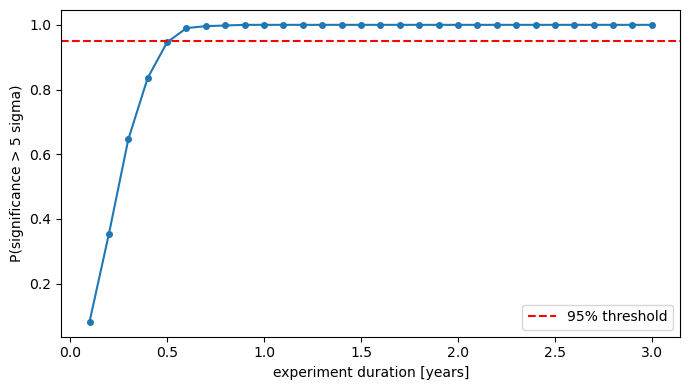

In [11]:
idx = np.where(probs >= 0.95)[0]
if len(idx) > 0:
    T_discovery = durations[idx[0]]
    print(f"minimum duration for 95% discovery chance: {T_discovery:.1f} years")
else:
    print("no duration in range achieves 95% - extend the scan")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(durations, probs, marker="o", markersize=4)
ax.axhline(0.95, color="red", linestyle="--", label="95% threshold")
ax.set_xlabel("experiment duration [years]")
ax.set_ylabel("P(significance > 5 sigma)")
ax.legend()
plt.tight_layout()
plt.savefig("plots/discovery_duration.png", dpi=150, bbox_inches="tight")
plt.show()